In [31]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import ggplot,geom_bar,theme_bw,labs,coord_flip,aes

In [2]:
df = pd.read_csv("/Users/abhimanyu/Developer/Projects/Income_classifier/Data/income_data.csv")
df.head()

,Workclass,Education,Marital-Status,Occupation,Relationship,Race,Sex,Native_country,Target
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [3]:
df.tail()

,Workclass,Education,Marital-Status,Occupation,Relationship,Race,Sex,Native_country,Target
30157,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,United-States,<=50K
30158,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,>50K
30159,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K
30160,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,United-States,<=50K
30161,Self-emp-inc,HS-grad,Married-civ-spouse,Exec-managerial,Wife,White,Female,United-States,>50K


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Workclass       30162 non-null  str  
 1   Education       30162 non-null  str  
 2   Marital-Status  30162 non-null  str  
 3   Occupation      30162 non-null  str  
 4   Relationship    30162 non-null  str  
 5   Race            30162 non-null  str  
 6   Sex             30162 non-null  str  
 7   Native_country  30162 non-null  str  
 8   Target          30162 non-null  str  
dtypes: str(9)
memory usage: 2.1 MB


In [5]:
df.describe()

,Workclass,Education,Marital-Status,Occupation,Relationship,Race,Sex,Native_country,Target
count,30162,30162,30162,30162,30162,30162,30162,30162,30162
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22286,9840,14065,4038,12463,25933,20380,27504,22654




Variable Workclass
Workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

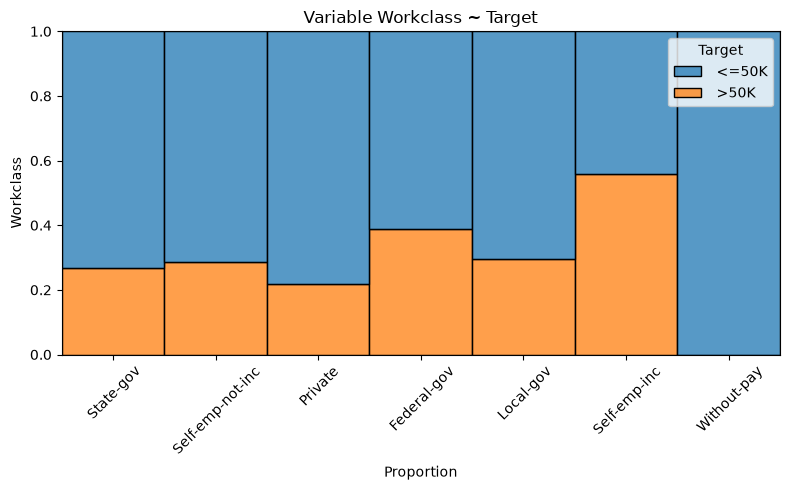



Variable Education
Education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          288
1st-4th          151
Preschool         45
Name: count, dtype: int64


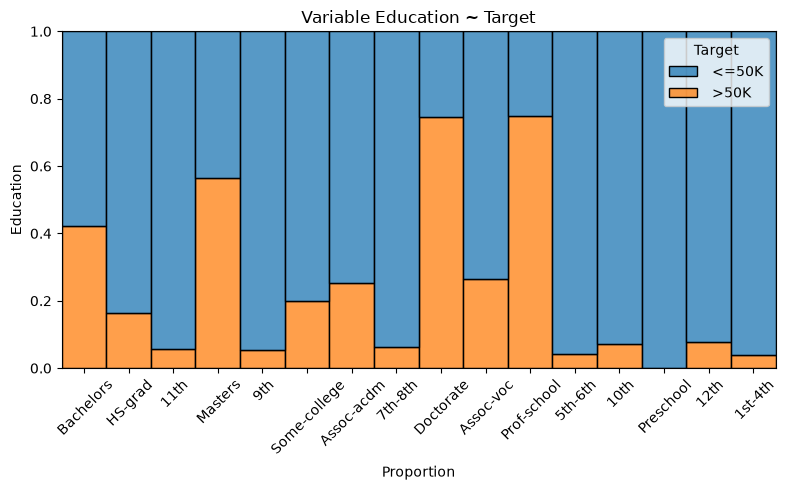



Variable Marital-Status
Marital-Status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64


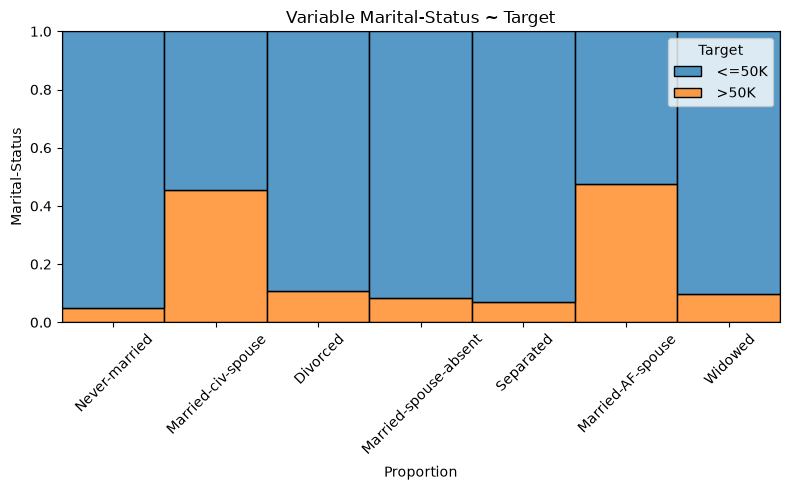



Variable Occupation
Occupation
Prof-specialty       4038
Craft-repair         4030
Exec-managerial      3992
Adm-clerical         3721
Sales                3584
Other-service        3212
Machine-op-inspct    1966
Transport-moving     1572
Handlers-cleaners    1350
Farming-fishing       989
Tech-support          912
Protective-serv       644
Priv-house-serv       143
Armed-Forces            9
Name: count, dtype: int64


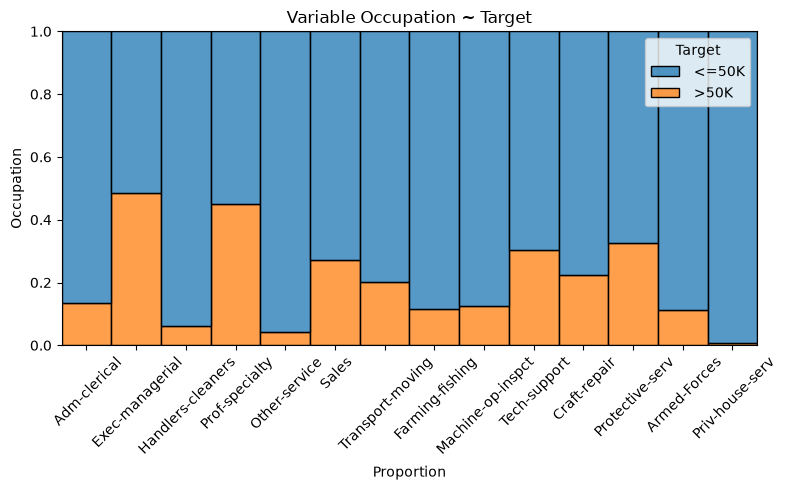



Variable Relationship
Relationship
Husband           12463
Not-in-family      7726
Own-child          4466
Unmarried          3212
Wife               1406
Other-relative      889
Name: count, dtype: int64


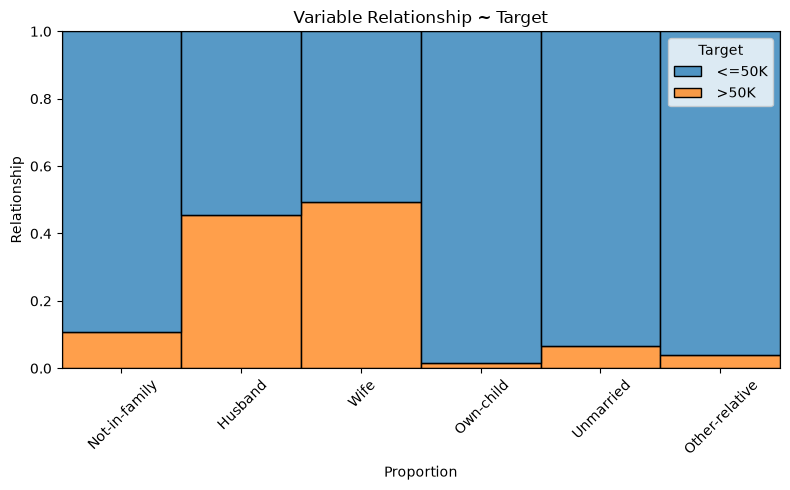



Variable Race
Race
White                 25933
Black                  2817
Asian-Pac-Islander      895
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64


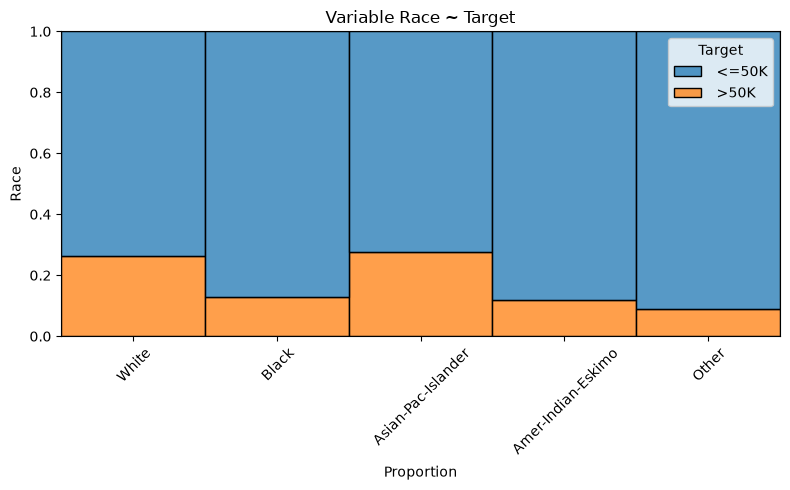



Variable Sex
Sex
Male      20380
Female     9782
Name: count, dtype: int64


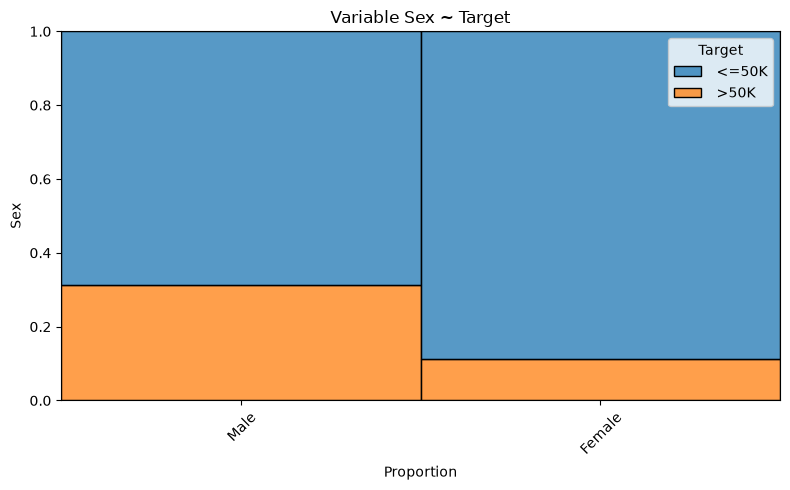



Variable Native_country
Native_country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
India                           100
El-Salvador                     100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Poland                           56
Columbia                         56
Iran                             42
Taiwan                           42
Haiti                            42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                 

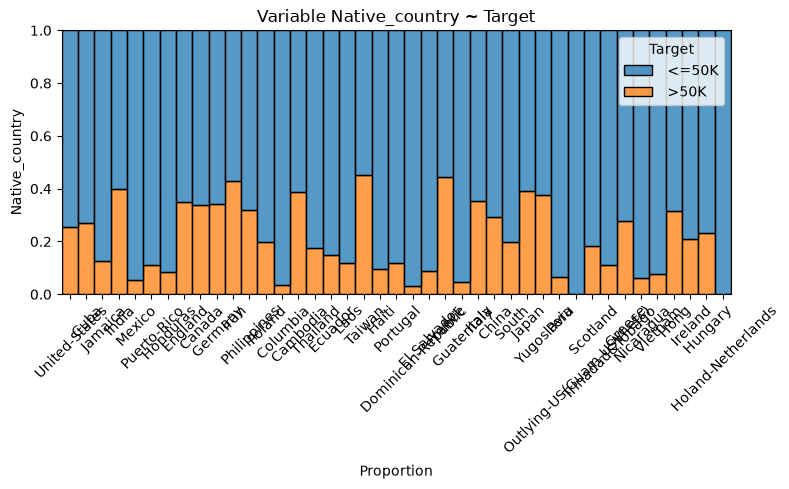

In [89]:
if not os.path.isdir("categorical_variable_plots"):
    os.mkdir("categorical_variable_plots")
for column in df.iloc[:,:-1].select_dtypes(include='str').columns:
    print(f"\n\nVariable {column}")
    print(df[column].value_counts())
    plt.figure(figsize=(8,5))
    sns.histplot(
        data=df,
        x= column,
        hue="Target",
        multiple="fill"
)
    plt.title(f"Variable {column} ~ Target")
    plt.xlabel("Proportion")
    plt.xticks(rotation=45)
    plt.ylabel(column)
    plt.tight_layout()
    plt.savefig(f"categorical_variable_plots/Variable {column}")
    plt.show()
    plt.close()